In [1]:
import xarray as xr
import numpy as np
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pymannkendall as mk
from dask.diagnostics import ProgressBar

In [2]:
# 2008-2020 MetOp-A Data (constant orbit)
# seasonal trends and min and max
# day and night


In [3]:
# compute monhtly means and stack them
lst_2008 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2008/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [4]:
lst_2009 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2009/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [5]:
lst_2010 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2010/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [6]:
lst_2011 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2011/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [7]:
lst_2012 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2012/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [8]:
lst_2013 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2013/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [9]:
lst_2014 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2014/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [10]:
lst_2015 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2015/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [11]:
lst_2016 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2016/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [12]:
lst_2017 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2017/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [13]:
lst_2018 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2018/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [14]:
lst_2019 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2019/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [15]:
lst_2020 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2020/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [99]:
# load water mask in the end !

In [16]:
lst_2020

<xarray.Dataset> Size: 101GB
Dimensions:      (lat: 800, lon: 7200, time: 366)
Coordinates:
  * lat          (lat) float32 3kB 50.03 50.08 50.12 50.17 ... 89.88 89.93 89.97
  * lon          (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * time         (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    LST          (lat, lon, time) float64 17GB dask.array<chunksize=(800, 7200, 1), meta=np.ndarray>
    satzen       (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    sunzen       (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    scan_time    (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    test_mae     (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    r2           (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>

In [17]:
# load the time series somewhere ?
results = {}

for year in range(2008, 2021):

    ds = globals()[f"lst_{year}"]   # load lst_1981, lst_1982, ...

    clean_LST = ds['LST'].where(ds['LST'] > 110, np.nan)
    monthly_mean = (
        clean_LST
        .resample(
            time='1MS'
        )
        .mean()
    )

    # Ensure bins exist even with no data
    # Xarray automatically creates them and fills with NaN

    results[year] = monthly_mean

combined = xr.concat([results[y] for y in range(2008, 2021)], dim="time")

In [18]:
combined

<xarray.DataArray 'LST' (lat: 800, lon: 7200, time: 156)> Size: 7GB
dask.array<concatenate, shape=(800, 7200, 156), dtype=float64, chunksize=(800, 7200, 1), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float32 3kB 50.03 50.08 50.12 50.17 ... 89.88 89.93 89.97
  * lon          (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    band         int64 8B 1
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 1kB 2008-01-01 2008-02-01 ... 2020-12-01

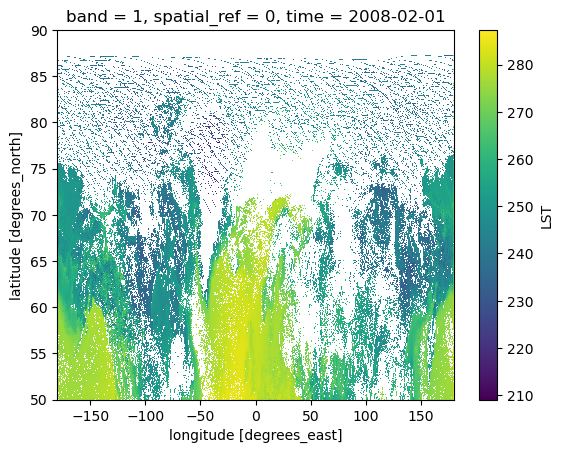

In [19]:
combined.isel(time=1).plot();

In [24]:
# spatial aggregation
# load cloud files
clouds = xr.open_dataset('../data/ice_flc_percent_2008_2020_2deg.nc')
example = clouds['ice_flc_percent'].isel(year=1, month=1)
#interp
combined_interp = combined.interp(lat=example.coords['latitude'], lon=example.coords['longitude'], method='nearest')

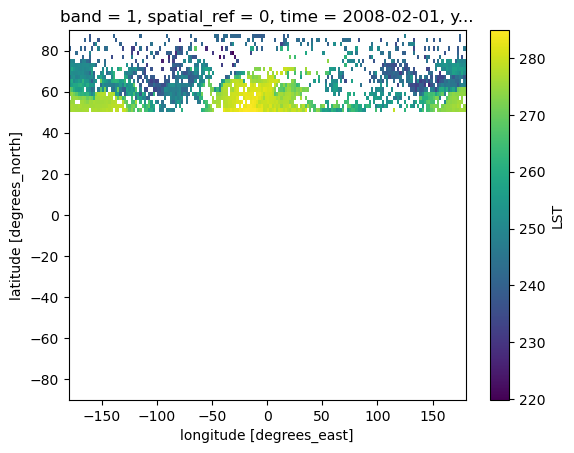

In [26]:
combined_interp.isel(time=1).plot();

In [27]:
climatology = combined_interp.groupby('time.season').mean("time")

In [ ]:
# interp water maks

In [28]:
water_mask = rioxarray.open_rasterio('/mnt/data7/nfs4/avh_lst/sdupuis/auxiliary/watermask50.tif')
water_mask = water_mask.rename({'y':'lat', 'x':'lon'})
water_mask = water_mask.isel(lat=slice(None, None, -1))

water_mask_crop = water_mask.sel(lat=slice(50,90))
water_mask_true = combined_interp.isel(time=0).copy(data=np.array(np.squeeze(water_mask_crop)))
ls_mask = water_mask_true.where(water_mask_true>0, np.nan)

ValueError: Data shape (800, 7200) must match shape of object (90, 180)

In [27]:
clim_masked = climatology * ls_mask

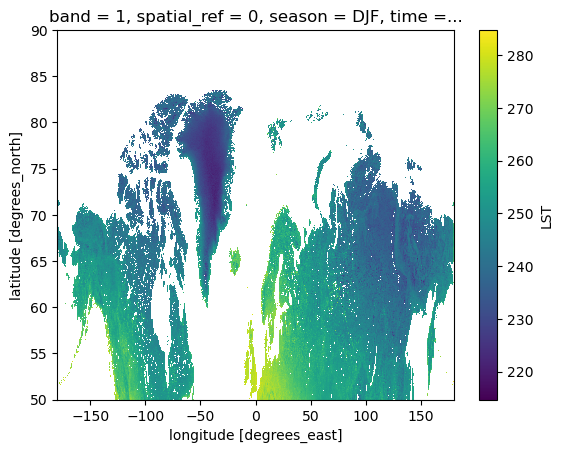

In [30]:
# remove water !!! from water mask -> and do nice subplots
clim_masked.sel(season='DJF').plot();

In [31]:
clim_loaded = clim_masked.load()

/tmp/ipykernel_18545/4127993170.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


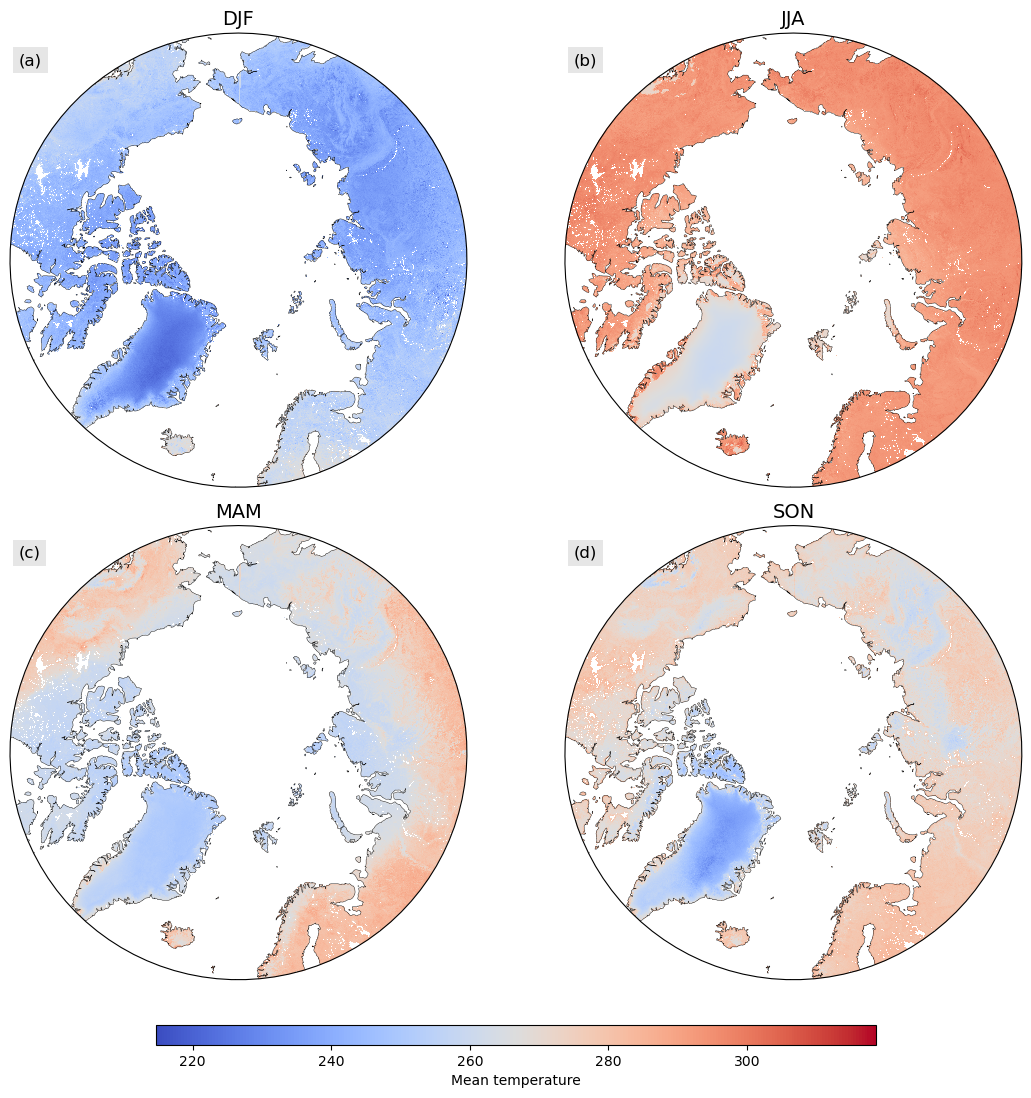

In [ ]:
# values are strange

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.transforms as mtransforms
import cartopy.crs as ccrs

vmin = float(clim_loaded.min())
vmax = float(clim_loaded.max())

proj = ccrs.NorthPolarStereo()

# --- get seasons dynamically (important!) ---
seasons = list(clim_loaded['season'].values)

# --- create mosaic layout (assumes 4 seasons) ---
fig, axs = plt.subplot_mosaic(
    [['(a)', '(b)'], ['(c)', '(d)']],
    figsize=(12, 10),
    subplot_kw=dict(projection=proj)
)

labels = ['(a)', '(b)', '(c)', '(d)']

# --- circular boundary ---
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# --- plotting loop ---
mappable = None

for i, (season, lab) in enumerate(zip(seasons, labels)):
    ax = axs[lab]

    da = clim_loaded.sel(season=season)

    mappable = da.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # --- map styling ---
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines(linewidth=0.3)

    ax.set_title(str(season), fontsize=14)

# --- panel labels ---
for lab, ax in axs.items():
    trans = mtransforms.ScaledTranslation(-10/72, 2/72, fig.dpi_scale_trans)
    ax.text(
        0.05, 0.95, lab,
        transform=ax.transAxes + trans,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(facecolor='0.9', edgecolor='none')
    )

# --- make space at bottom ---
fig.subplots_adjust(bottom=0.12)

# --- add colorbar axis manually ---
cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.02])  # [left, bottom, width, height]

cbar = fig.colorbar(
    mappable,
    cax=cbar_ax,
    orientation='horizontal'
)

cbar.set_label(' Mean LST [K]')

plt.tight_layout()
plt.savefig('meanstate_arctic_day.png', dpi=300)

In [38]:
# compute trends

In [40]:
# compute trends
winter = combined.sel(time=combined.time.dt.month.isin([1,2, 12]))

In [41]:
winter['time']= winter['time'] + np.timedelta64(10000000000000000, 'ns')

In [42]:
winter_data = winter.groupby('time.year').mean()

In [43]:
winter_masked = winter_data * ls_mask

In [44]:
winter_masked = winter_masked.chunk({'year':-1, 'lon':1000, 'lat':100})

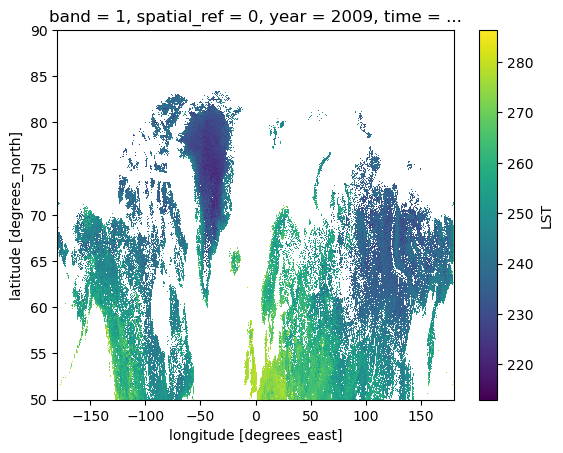

In [45]:
winter_masked.isel(year=1).plot();

In [61]:
def mk_test_p(y):
    if np.count_nonzero(np.isnan(y)) > 9:
        #print('catched_error')
        return np.nan
    #results = mk.original_test(y).slope
    p_vals = mk.original_test(y).p
    return p_vals

def mann_kendall_p(y, dim):
    return xr.apply_ufunc(
        mk_test_p,
        y,
        input_core_dims=[[dim]],
        dask ='parallelized',
        vectorize=True,
        output_dtypes=[float],)

In [62]:
with ProgressBar():
    p_val_winter = mann_kendall_p(winter_masked, dim="year").compute()
    # mask out oceans
p_val_winter_masked = p_val_winter*ls_mask
ds_p_val = p_val_winter_masked.to_dataset(name='p_val')
ds_p_val.to_netcdf('winter_p_val_DAY.nc', format='NETCDF4')

[########################################] | 100% Completed | 34m 26s


In [46]:
def mk_test(y):
    if np.count_nonzero(np.isnan(y)) > 9:
        #print('catched_error')
        return np.nan
    results = mk.original_test(y).slope
    #p_vals = mk.original_test(y).p
    return results

In [47]:
def mann_kendall(y, dim):
    return xr.apply_ufunc(
        mk_test,
        y,
        input_core_dims=[[dim]],
        dask ='parallelized',
        vectorize=True,
        output_dtypes=[float],)

In [50]:
with ProgressBar():
    res = mann_kendall(winter_masked, dim="year").compute()

[########################################] | 100% Completed | 34m 0ss


In [51]:
# mask out oceans
res_masked = res*ls_mask

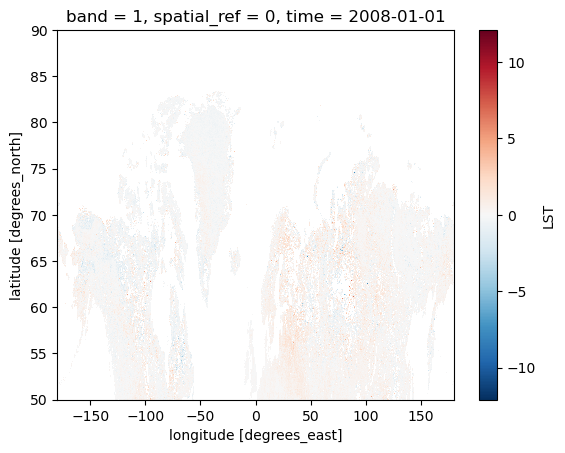

In [52]:
# apply mask and then save the data! 
res_masked.plot();

In [53]:
ds_trend = res_masked.to_dataset(name='trend')
ds_trend.to_netcdf('winter_trend_DAY.nc', format='NETCDF4')

In [65]:
# compute trends
spring = combined.sel(time=combined.time.dt.month.isin([3,4, 5]))
spring_data = spring.groupby('time.year').mean()
spring_data = spring_data.chunk({'year':-1, 'lon':1000, 'lat':100})

In [ ]:
with ProgressBar():
    res_spring = mann_kendall(spring_data, dim="year").compute()

[########################################] | 100% Completed | 34m 45s


In [56]:
spring_masked = res_spring*ls_mask
spring_trend = spring_masked.to_dataset(name='trend')
spring_trend.to_netcdf('spring_trend_day.nc', format='NETCDF4')

In [66]:
with ProgressBar():
    p_val_spring = mann_kendall_p(spring_data, dim="year").compute()
    # mask out oceans
p_val_spring_masked = p_val_spring*ls_mask
ds_p_val_spring = p_val_spring_masked.to_dataset(name='p_val')
ds_p_val_spring.to_netcdf('spring_p_val_DAY.nc', format='NETCDF4')

[########################################] | 100% Completed | 78m 50s


In [67]:
# compute trends
summer = combined.sel(time=combined.time.dt.month.isin([6,7, 8]))
summer_data = summer.groupby('time.year').mean()
summer_data = summer_data.chunk({'year':-1, 'lon':1000, 'lat':100})
with ProgressBar():
    res_summer = mann_kendall(summer_data, dim="year").compute()

[########################################] | 100% Completed | 95m 28s


In [58]:
summer_masked = res_summer*ls_mask
summer_trend = summer_masked.to_dataset(name='trend')
summer_trend.to_netcdf('summer_trend_day.nc', format='NETCDF4')

In [68]:
with ProgressBar():
    p_val_summer = mann_kendall_p(summer_data, dim="year").compute()
    # mask out oceans
p_val_summer_masked = p_val_summer*ls_mask
ds_p_val_summer = p_val_summer_masked.to_dataset(name='p_val')
ds_p_val_summer.to_netcdf('summer_p_val_DAY.nc', format='NETCDF4')

[########################################] | 100% Completed | 88m 52s


In [ ]:
# compute trends
fall = combined.sel(time=combined.time.dt.month.isin([9,10, 11]))
fall_data = fall.groupby('time.year').mean()
fall_data = fall_data.chunk({'year':-1, 'lon':1000, 'lat':100})
with ProgressBar():
    res_fall = mann_kendall(fall_data, dim="year").compute()

[########################################] | 100% Completed | 74m 19s


: 

In [60]:
fall_masked = res_fall*ls_mask
fall_trend = fall_masked.to_dataset(name='trend')
fall_trend.to_netcdf('fall_trend_day.nc', format='NETCDF4')

In [ ]:
with ProgressBar():
    p_val_fall = mann_kendall_p(fall_data, dim="year").compute()
    # mask out oceans
p_val_fall_masked = p_val_fall*ls_mask
ds_p_val_fall = p_val_fall_masked.to_dataset(name='p_val')
ds_p_val_fall.to_netcdf('fall_p_val_DAY.nc', format='NETCDF4')